## Practice Activity 7-1: Association Rules Mining

In the reading you analyzed transactions from a bakery. In this activity you will carry out a very similar analysis for purchases from a grocery store.

In [75]:
import pandas as pd

from plotnine import *

from mlxtend.frequent_patterns import apriori, association_rules

# to stop an annoying warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

## Groceries data set

- One month (30 days) of real point-of-sale transactions from a grocery store.
- 9,835 transactions (baskets).
- 169 product categories, such as whole milk, yogurt, bottled beer, etc.
- Source: the data set `Groceries` in the R package `arules`, provided by Hahsler, Hornik, and Reutterer. The copy we use is a plain-text version hosted on GitHub.


The file format is different from the bakery file. The bakery file had one row per item bought. This file has **one line per transaction**, and each line is a comma-separated list of the items in that basket. Different baskets have different numbers of items.

The next cell reads each line into a single text column. (Normal CSV reading expects every row to have the same number of columns, so we read each line as one string, using a separator `"|"` that never occurs in the file.)

In [76]:
import csv

raw = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv",
    header=None,             # the file has no header row: line 1 is already a transaction
    names=["basket"],        # name the one column we create
    sep="|",                 # "|" never appears in this file, so each whole line lands in one column
    quoting=csv.QUOTE_NONE,  # treat any quote characters as ordinary text
)

In [77]:
raw

,basket
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."
...,...
9830,"sausage,chicken,beef,hamburger meat,citrus fru..."
9831,cooking chocolate
9832,"chicken,citrus fruit,other vegetables,butter,y..."
9833,"semi-finished bread,bottled water,soda,bottled..."


We'll start with the data in long format like in the reading.

- Make a column `basket_id` from the row number (`raw.index`).
- Split the text in `raw["basket"]` at the commas, using `.str.split(",")`. This produces a *list* of items in each row.
- Use `.explode(...)` on the column of lists to get one row per item.
- Keep only `basket_id` and `item`, and use `.reset_index(drop=True)`.
- Trim spaces

In [78]:
long = (
    raw
    .assign(basket_id=raw.index)                    # use the row number as the basket ID
    .assign(item=raw["basket"].str.split(","))      # "milk,bread" becomes ["milk", "bread"]
    .explode("item")                                # one row per (basket, item)
    [["basket_id", "item"]]                         # keep only the two columns we need
    .reset_index(drop=True)                         # renumber the rows 0, 1, 2, ...
)

long["item"] = long["item"].str.strip()             # remove stray leading/trailing spaces

long

,basket_id,item
0,0,citrus fruit
1,0,semi-finished bread
2,0,margarine
3,0,ready soups
4,1,tropical fruit
...,...,...
43362,9834,chicken
43363,9834,tropical fruit
43364,9834,other vegetables
43365,9834,vinegar


1. Build the transaction-by-item table `basket`. There should be one row per basket, one column per item, with `True` if the item is in the basket and `False` otherwise.

In [79]:
basket = pd.crosstab(long["basket_id"], long["item"]) > 0

print(basket.shape)
basket.head()

(9835, 169)


item,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
basket_id,,,,,,,,,,,,,,,,,,,,,
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


2.  Compute the size (number of items) of each basket and store it in `basket_sizes`.

In [80]:
basket_sizes = basket.sum(axis=1)

basket_sizes.head()

basket_id
0    4
1    3
2    1
3    4
4    4
dtype: int64

3. Summarize the distribution of the number of items.

In [81]:
basket_sizes.describe()

count    9835.000000
mean        4.409456
std         3.589385
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        32.000000
dtype: float64

4. Compute the support of every item, sorted from largest to smallest, and store it in `item_support`. Then make a horizontal bar chart of the 15 most popular items.

In [82]:
item_support = basket.mean().sort_values(ascending=False)

item_support.head(15)

item
whole milk          0.255516
other vegetables    0.193493
rolls/buns          0.183935
soda                0.174377
yogurt              0.139502
bottled water       0.110524
root vegetables     0.108998
tropical fruit      0.104931
shopping bags       0.098526
sausage             0.093950
pastry              0.088968
citrus fruit        0.082766
bottled beer        0.080529
newspapers          0.079817
canned beer         0.077682
dtype: float64

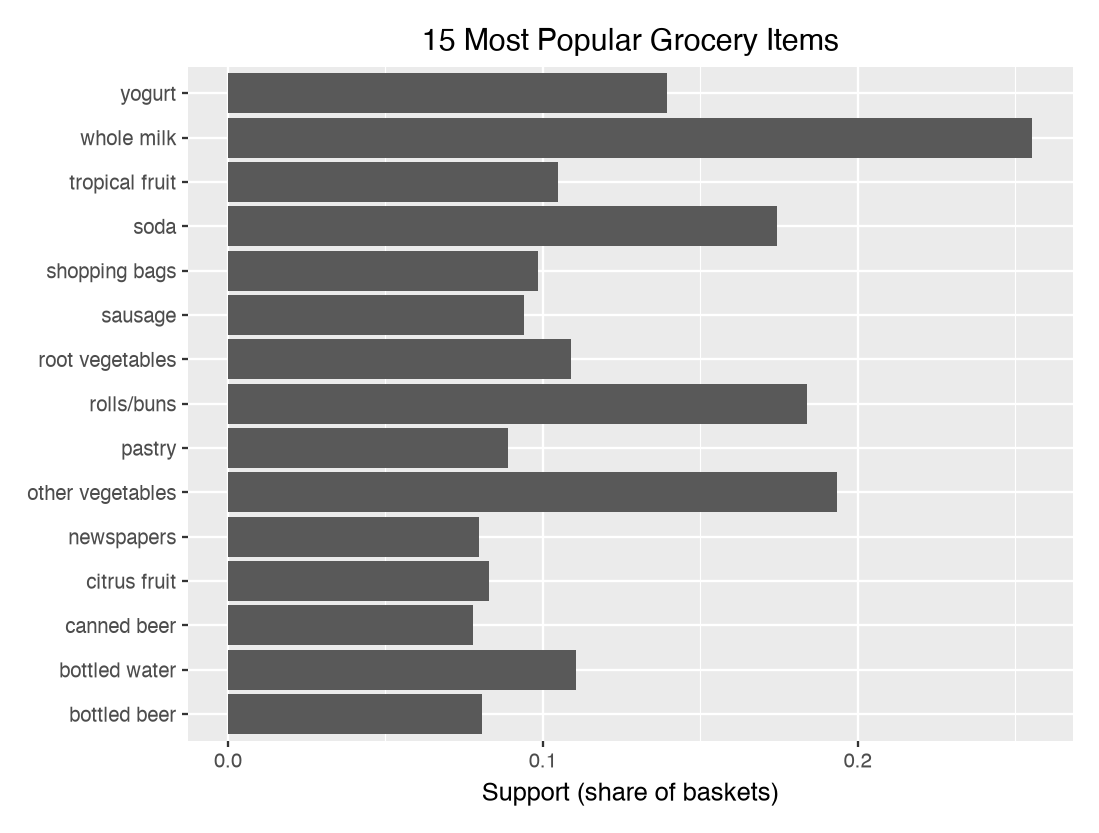

In [83]:
top_15 = (
    item_support.head(15)
    .sort_values()
    .reset_index()
)
top_15.columns = ["item", "support"]

(
    ggplot(top_15, aes(x="item", y="support"))
    + geom_col()
    + coord_flip()
    + labs(
        title="15 Most Popular Grocery Items",
        x="",
        y="Support (share of baskets)"
    )
)

5. Consider the basket sizes and the item supports. Which item is most popular, and in what percentage of baskets does it appear? Which items are most common? What does this suggest about the "popular items co-occur just by chance" problem discussed in the reading?

In [84]:
print(f"Most popular item: {item_support.index[0]}")
print(f"Support: {item_support.iloc[0]:.3f} ({item_support.iloc[0] * 100:.1f}%)")

item_support.head(10)

Most popular item: whole milk
Support: 0.256 (25.6%)


item
whole milk          0.255516
other vegetables    0.193493
rolls/buns          0.183935
soda                0.174377
yogurt              0.139502
bottled water       0.110524
root vegetables     0.108998
tropical fruit      0.104931
shopping bags       0.098526
sausage             0.093950
dtype: float64

whole milk should be the most popular item, in about 25% of baskets. Because some items are bought very often, they can appear together just because both are popular—not necessarily because one item causes people to buy the other. That is why lift matters.

6. Consider the rule **{yogurt} → {whole milk}**. Compute and interpret the confidence of this rule.

Of baskets containing yogurt, the confidence tells you the percentage that also contain whole milk.


In [85]:
support_yogurt = basket["yogurt"].mean()
support_whole_milk = basket["whole milk"].mean()
support_both = basket[["yogurt", "whole milk"]].all(axis=1).mean()

confidence_yogurt_to_milk = support_both / support_yogurt

print(f"Support of yogurt: {support_yogurt:.3f}")
print(f"Support of whole milk: {support_whole_milk:.3f}")
print(f"Support of both: {support_both:.3f}")
print(f"Confidence of yogurt → whole milk: {confidence_yogurt_to_milk:.3f}")

Support of yogurt: 0.140
Support of whole milk: 0.256
Support of both: 0.056
Confidence of yogurt → whole milk: 0.402


7. Compute and interpret the **lift** of {yogurt} → {whole milk}.

In [86]:
lift_yogurt_to_milk = support_both / (support_yogurt * support_whole_milk)

print(f"Lift of yogurt → whole milk: {lift_yogurt_to_milk:.3f}")

Lift of yogurt → whole milk: 1.572


A lift above 1 means yogurt and whole milk occur together more often than expected by chance.

8. Now compute and interpret the confidence and lift for the rule {whole milk} → {yogurt}.

In [87]:
confidence_milk_to_yogurt = support_both / support_whole_milk
lift_milk_to_yogurt = support_both / (support_whole_milk * support_yogurt)

print(f"Confidence of whole milk → yogurt: {confidence_milk_to_yogurt:.3f}")
print(f"Lift of whole milk → yogurt: {lift_milk_to_yogurt:.3f}")

Confidence of whole milk → yogurt: 0.219
Lift of whole milk → yogurt: 1.572


The confidence changes because the item on the left side changed. The lift stays the same because lift measures the relationship between the two items.

9. Write two functions.

- `support(items, onehot)`: returns the share of baskets that contain **all** of the items in the list `items`.
- `rule_metrics(antecedent, consequent, onehot)`: returns a Pandas Series with the `support`, `confidence`, and `lift` of the rule `antecedent -> consequent`. Both `antecedent` and `consequent` are *lists* of items.

Test the functions on `["yogurt"]` → `["whole milk"]`. The values should match the ones you computed earlier.

In [88]:
def support(items, onehot):
    """Return the share of baskets containing every item in items."""
    return onehot[items].all(axis=1).mean()


def rule_metrics(antecedent, consequent, onehot):
    """Return support, confidence, and lift for antecedent → consequent."""
    
    support_antecedent = support(antecedent, onehot)
    support_consequent = support(consequent, onehot)
    support_rule = support(antecedent + consequent, onehot)
    
    confidence = support_rule / support_antecedent
    lift = support_rule / (support_antecedent * support_consequent)
    
    return pd.Series({
        "support": support_rule,
        "confidence": confidence,
        "lift": lift
    })


rule_metrics(["yogurt"], ["whole milk"], basket)

support       0.056024
confidence    0.401603
lift          1.571735
dtype: float64

10. Whole milk is in about a quarter of all baskets. Consider the rules `{X} → {whole milk}` for the five antecedents `X` in the next cell. Before running anything, predict: for which of these will the lift be **above 1**? For which might the confidence look decent but the lift be **close to or below 1**? Just think about this before proceeding.

In [89]:
antecedents = pd.Series(["yogurt", "rolls/buns", "bottled water", "soda", "other vegetables"])

11. Compute the support, confidence, and lift of `{X} → {whole milk}` for each of the five antecedents above, and display the results sorted by lift (largest first). Compare to your predictions. Hint: Use `apply` with `lambda` on the Series of antecedents.


In [90]:
results = antecedents.to_frame(name="antecedent").join(
    antecedents.apply(
        lambda item: rule_metrics([item], ["whole milk"], basket)
    )
)

results.sort_values("lift", ascending=False)

,antecedent,support,confidence,lift
0,yogurt,0.056024,0.401603,1.571735
4,other vegetables,0.074835,0.386758,1.513634
2,bottled water,0.034367,0.310948,1.216940
1,rolls/buns,0.056634,0.307905,1.205032
3,soda,0.040061,0.229738,0.899112


12. Run `apriori` on `basket` with `min_support=0.01` and store the result in `frequent_itemsets`. Then add a column `n_items` giving the number of items in each itemset.

In [91]:
frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets["n_items"] = frequent_itemsets["itemsets"].apply(len)

print(frequent_itemsets.shape)
frequent_itemsets.head()

(333, 3)


,support,itemsets,n_items
0,0.033452,(UHT-milk),1
1,0.017692,(baking powder),1
2,0.052466,(beef),1
3,0.033249,(berries),1
4,0.026029,(beverages),1


13. Generate the rules with `make_rules`, keeping rules with confidence of at least 0.20. Store them in `rules` and print how many there are.

In [92]:
def make_rules(frequent_itemsets, min_confidence):
    return association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )


rules = make_rules(frequent_itemsets, 0.20)

print(len(rules), "rules")
rules.head()

234 rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(other vegetables),0.052466,0.193493,0.019725,0.375969,1.943066,1.0,0.009574,1.292416,0.512224,0.087191,0.226255,0.238957
1,(beef),(rolls/buns),0.052466,0.183935,0.013625,0.259690,1.411858,1.0,0.003975,1.102329,0.307866,0.061159,0.092830,0.166882
2,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455
3,(beef),(whole milk),0.052466,0.255516,0.021251,0.405039,1.585180,1.0,0.007845,1.251315,0.389597,0.074113,0.200841,0.244103
4,(beef),(yogurt),0.052466,0.139502,0.011693,0.222868,1.597601,1.0,0.004374,1.107275,0.394774,0.064862,0.096882,0.153344


14. Make the rules easier to read. Create a copy `rules_display` of `rules` and add three columns:

- `antecedent`: the antecedent items as text, e.g. `"tropical fruit, yogurt"`
- `consequent`: the consequent items as text
- `transactions`: the number of baskets that contain the whole rule (support times the number of baskets, rounded to an integer)

Then display the columns `antecedent`, `consequent`, `support`, `confidence`, `lift`, `transactions` for the first 8 rules.

In [93]:
rules_display = rules.copy()

rules_display["antecedent"] = rules_display["antecedents"].apply(
    lambda items: ", ".join(sorted(items))
)

rules_display["consequent"] = rules_display["consequents"].apply(
    lambda items: ", ".join(sorted(items))
)

rules_display["transactions"] = (
    rules_display["support"] * len(basket)
).round().astype(int)

show = [
    "antecedent",
    "consequent",
    "support",
    "confidence",
    "lift",
    "transactions"
]

rules_display[show].head(8).round(3)

,antecedent,consequent,support,confidence,lift,transactions
0,beef,other vegetables,0.020,0.376,1.943,194
1,beef,rolls/buns,0.014,0.260,1.412,134
2,beef,root vegetables,0.017,0.331,3.040,171
3,beef,whole milk,0.021,0.405,1.585,209
4,beef,yogurt,0.012,0.223,1.598,115
5,berries,other vegetables,0.010,0.309,1.596,101
6,berries,whole milk,0.012,0.355,1.388,116
7,berries,yogurt,0.011,0.318,2.280,104


15. Show the 10 rules with the highest **confidence**. What do the highest-confidence rules have in common? Why is confidence alone a poor guide here?

high-confidence rules often have very popular products, especially whole milk, as the consequent. Confidence alone can be misleading because a popular product would appear in many baskets anyway.

In [94]:
rules_display.sort_values(
    "confidence",
    ascending=False
)[show].head(10).round(3)

,antecedent,consequent,support,confidence,lift,transactions
157,"citrus fruit, root vegetables",other vegetables,0.010,0.586,3.030,102
185,"root vegetables, tropical fruit",other vegetables,0.012,0.585,3.021,121
163,"curd, yogurt",whole milk,0.010,0.582,2.279,99
154,"butter, other vegetables",whole milk,0.011,0.574,2.245,113
222,"root vegetables, tropical fruit",whole milk,0.012,0.570,2.231,118
224,"root vegetables, yogurt",whole milk,0.015,0.563,2.203,143
166,"domestic eggs, other vegetables",whole milk,0.012,0.553,2.162,121
233,"whipped/sour cream, yogurt",whole milk,0.011,0.525,2.053,107
214,"rolls/buns, root vegetables",whole milk,0.013,0.523,2.047,125
172,"other vegetables, pip fruit",whole milk,0.014,0.518,2.025,133


16. Show the 10 rules with the highest **lift**. Compare this list with the highest-confidence list. What kinds of products appear now? Look at the `support` and `transactions` columns: how much evidence is each of these rules based on?

In [95]:
rules_display.sort_values(
    "lift",
    ascending=False
)[show].head(10).round(3)

,antecedent,consequent,support,confidence,lift,transactions
158,"citrus fruit, other vegetables",root vegetables,0.010,0.359,3.295,102
208,"other vegetables, yogurt",whipped/sour cream,0.010,0.234,3.267,100
186,"other vegetables, tropical fruit",root vegetables,0.012,0.343,3.145,121
2,beef,root vegetables,0.017,0.331,3.040,171
157,"citrus fruit, root vegetables",other vegetables,0.010,0.586,3.030,102
185,"root vegetables, tropical fruit",other vegetables,0.012,0.585,3.021,121
190,root vegetables,"other vegetables, whole milk",0.023,0.213,2.842,228
189,"other vegetables, whole milk",root vegetables,0.023,0.310,2.842,228
155,butter,"other vegetables, whole milk",0.011,0.207,2.771,113
164,"curd, whole milk",yogurt,0.010,0.385,2.761,99


17. Create `interesting_rules`: the rules with **confidence of at least 0.30 and lift of at least 1.5**, sorted by lift (largest first).


In [96]:
interesting_rules = (
    rules_display[
        (rules_display["confidence"] >= 0.30)
        & (rules_display["lift"] >= 1.5)
    ]
    .sort_values("lift", ascending=False)
)

interesting_rules[show].round(3)

,antecedent,consequent,support,confidence,lift,transactions
158,"citrus fruit, other vegetables",root vegetables,0.010,0.359,3.295,102
186,"other vegetables, tropical fruit",root vegetables,0.012,0.343,3.145,121
2,beef,root vegetables,0.017,0.331,3.040,171
157,"citrus fruit, root vegetables",other vegetables,0.010,0.586,3.030,102
185,"root vegetables, tropical fruit",other vegetables,0.012,0.585,3.021,121
...,...,...,...,...,...,...
89,onions,whole milk,0.012,0.390,1.527,119
72,hygiene articles,whole milk,0.013,0.389,1.522,126
17,brown bread,whole milk,0.025,0.389,1.521,248
106,other vegetables,whole milk,0.075,0.387,1.514,736


18. Choose **one** rule from the table and interpret its **support**, **confidence**, and **lift** with numbers, as you did for {yogurt} → {whole milk}.

In [97]:
chosen_rule = interesting_rules[show].iloc[0]

chosen_rule

antecedent      citrus fruit, other vegetables
consequent                     root vegetables
support                               0.010371
confidence                            0.359155
lift                                  3.295045
transactions                               102
Name: 158, dtype: object

The rule {citrus fruit, other vegetables} → {root vegetables} has support of 0.0104, meaning these items appear together in about 1.04% of all baskets (102 baskets). Its confidence is 0.3592, meaning 35.92% of baskets containing citrus fruit and other vegetables also contain root vegetables. Its lift is 3.30, meaning this combination appears about 3.30 times more often than expected by chance.

19. The manager wants to **increase sales of yogurt**. Which products should the store link to yogurt (shelf placement, a joint promotion, a recommendation)?

The store should link yogurt with curd and whole milk first because this combination has the strongest relationship with yogurt (lift = 2.76). Other good products to promote or place near yogurt are tropical fruit, other vegetables, whipped/sour cream, citrus fruit, curd, berries, and cream cheese.

In [98]:
yogurt_recommendations = (
    interesting_rules[
        interesting_rules["consequent"].eq("yogurt")
    ]
    .sort_values(["lift", "support"], ascending=False)
)

yogurt_recommendations[show].head(10).round(3)

,antecedent,consequent,support,confidence,lift,transactions
164,"curd, whole milk",yogurt,0.010,0.385,2.761,99
231,"tropical fruit, whole milk",yogurt,0.015,0.358,2.568,149
209,"other vegetables, whipped/sour cream",yogurt,0.010,0.352,2.524,100
203,"other vegetables, tropical fruit",yogurt,0.012,0.343,2.457,121
232,"whipped/sour cream, whole milk",yogurt,0.011,0.338,2.420,107
162,"citrus fruit, whole milk",yogurt,0.010,0.337,2.413,101
47,curd,yogurt,0.017,0.324,2.326,170
7,berries,yogurt,0.011,0.318,2.280,104
43,cream cheese,yogurt,0.012,0.313,2.242,122


---
## References and attribution


- Hahsler, M., Gr&uuml;n, B., and Hornik, K. (2005). arules: A computational environment for mining association rules and frequent item sets. *Journal of Statistical Software*, 14(15). (The R package that distributes the data.)
- Data copy: GitHub repository `stedy/Machine-Learning-with-R-datasets` (`groceries.csv`), the data used in Lantz, B., *Machine Learning with R*.
- Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *Journal of Open Source Software*, 3(24), 638. <https://doi.org/10.21105/joss.00638>


**Preparation of this notebook:** drafted with the assistance of generative AI tools (ChatGPT and Claude).